In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wangboluo/mcm2024/train.csv
/kaggle/input/datasets/wangboluo/mcm2024/test.csv


In [3]:
import pandas as pd
import numpy as np

# Use Kaggle path from your screenshot
train_path = "/kaggle/input/datasets/wangboluo/mcm2024/train.csv"

data = pd.read_csv(train_path)

print(data.head())

   acc_x  acc_y     acc_z    timestamp  Activity
0  -5.09   8.50 -1.266692  1887.012279         0
1  -5.18   8.35 -1.375655  1887.062297         0
2  -5.20   9.34 -1.334794  1887.112285         0
3  -4.25   9.11 -1.266692  1887.162273         0
4  -3.30   8.96 -1.307553  1887.212260         0


In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop missing
data = data.dropna()

# Features (adjust if column names differ)
X = data[['acc_x','acc_y','acc_z']].values

# Normalize
X = StandardScaler().fit_transform(X)

# Labels
y = LabelEncoder().fit_transform(data['Activity'])

In [6]:
def make_windows(X, y, size=128, step=64):
    X_w, y_w = [], []
    
    for i in range(0, len(X)-size, step):
        X_w.append(X[i:i+size])
        y_w.append(np.bincount(y[i:i+size]).argmax())
    
    return np.array(X_w), np.array(y_w)

X_w, y_w = make_windows(X, y)

print(X_w.shape)

(13448, 128, 3)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_w, y_w, test_size=0.2)

In [8]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        
        self.conv = nn.Conv1d(3, 16, 3)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(16*63, n_classes)

    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.pool(torch.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [9]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

model = SimpleCNN(len(np.unique(y)))
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    out = model(X_train)
    loss = loss_fn(out, y_train)

    opt.zero_grad()
    loss.backward()
    opt.step()

    pred = out.argmax(1)
    acc = accuracy_score(y_train, pred)

    print(f"Epoch {epoch+1} | Loss {loss.item():.4f} | Acc {acc:.4f}")

Epoch 1 | Loss 1.7688 | Acc 0.2308
Epoch 2 | Loss 1.5450 | Acc 0.4462
Epoch 3 | Loss 1.4141 | Acc 0.4502
Epoch 4 | Loss 1.3515 | Acc 0.4531
Epoch 5 | Loss 1.3243 | Acc 0.4518


Test Accuracy: 0.45390334572490704


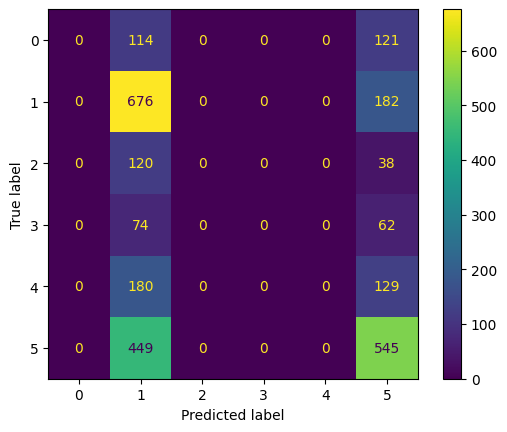

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pred = model(X_test).argmax(1)

print("Test Accuracy:", accuracy_score(y_test, pred))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()